# Issues we need to account for:
    [python for MRI analysis DAY1](https://www.youtube.com/watch?v=gMuxB18Cr0o) -- for fMRI especially
	- we have whole head images, we just want the brain
	- fMRI image and T1 image are not aligned
	- fMRI is distorted due to changing magnetic field in some area of brain
	- Participants move in scanners, fMRI image isn't aligned to it self
	- Movement actually influences the fMRI signal, we want brain signals not motion signals.
	- All subject aren't aligned to each other, need to warp images to a template (we need some sort of normalisation)

pre-processing for T1

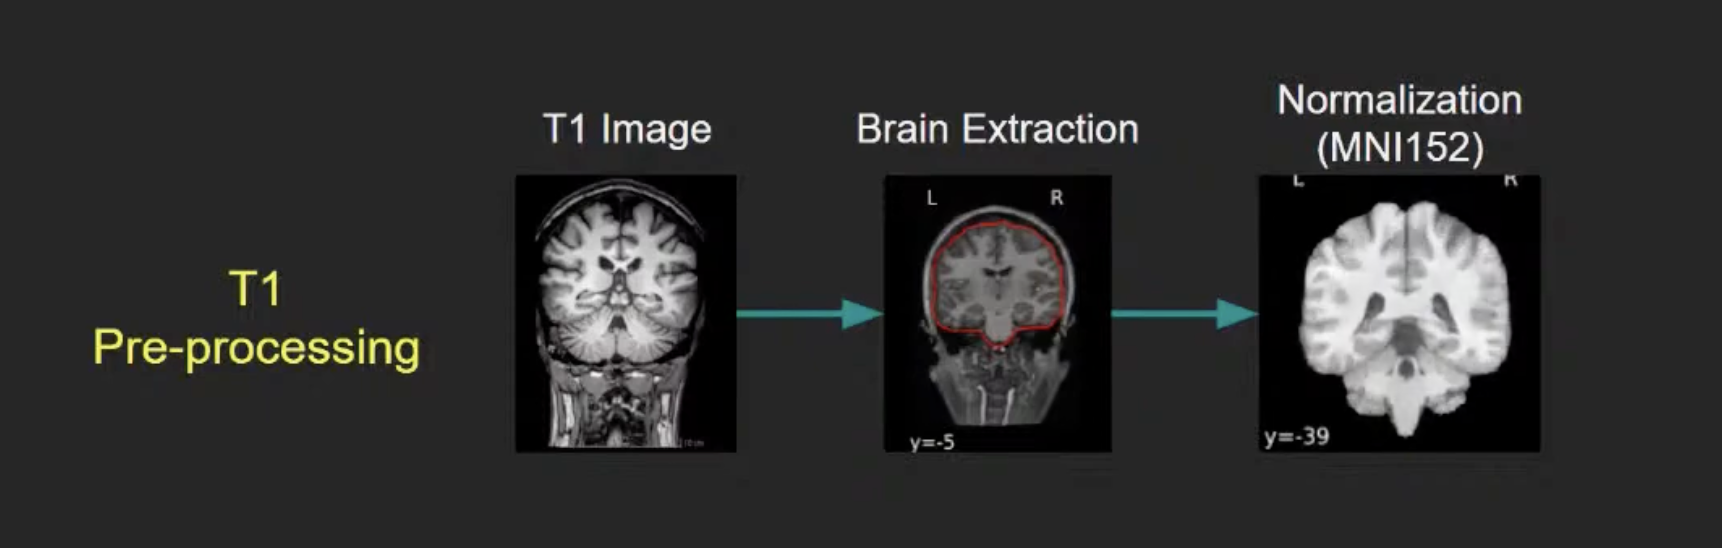

In [1]:
import nibabel as nib
import matplotlib.pyplot as plt

plt.style.use("dark_background")

# fmri_path = "../data/SIMON_data/SIMON_BIDS/sub-032633/ses-001/anat/sub-032633_ses-001_run-1_T1w.nii.gz"
fmri_path = "../data/SIMON_BIDS/sub-032633/ses-001/anat/sub-032633_ses-001_run-1_T1w.nii.gz"
img = nib.load(fmri_path)
data = img.get_fdata()
affine = img.affine

print("Shape:", data.shape)
print("Voxel size (mm):", img.header.get_zooms()[:3])

Shape: (171, 256, 256)
Voxel size (mm): (np.float32(1.0), np.float32(1.0), np.float32(1.0))


# N4 correction

In [1]:
import SimpleITK as sitk
import nibabel as nib
import numpy as np

# 1. Load the image using SimpleITK
# (SimpleITK handles the Affine/Spacing automatically)
fmri_path = "../data/SIMON_BIDS/sub-032633/ses-001/anat/sub-032633_ses-001_run-1_T1w.nii.gz"
input_image = sitk.ReadImage(fmri_path)

input_image_float = sitk.Cast(input_image, sitk.sitkFloat32)

# 2. Execute N4 Bias Field Correction
# This will 'flatten' the lighting of the brain
mask_for_n4 = sitk.OtsuThreshold(input_image_float, 0, 1, 200) # Simple internal mask for N4
corrector = sitk.N4BiasFieldCorrectionImageFilter()
corrected_image = corrector.Execute(input_image_float, mask_for_n4)

# 3. Convert back to Numpy to see the difference in Histogram
original_data = sitk.GetArrayFromImage(input_image_float)
corrected_data = sitk.GetArrayFromImage(corrected_image)

# # 4. Save the 'clean' image for the next steps
# sitk.WriteImage(corrected_image, 'preprocessed_t1.nii.gz')

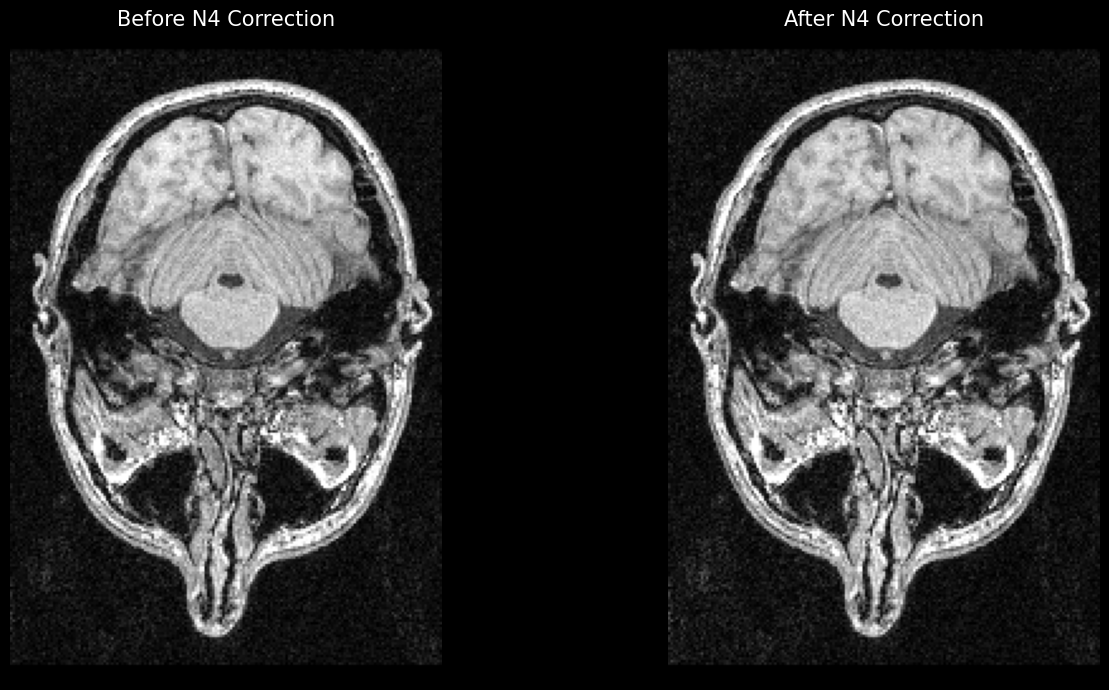

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Select a middle slice
slice_idx = original_data.shape[0] // 2

fig, axes = plt.subplots(1, 2, figsize=(15, 7), facecolor='black')

# Use the same vmin/vmax for both to ensure a fair comparison
# We'll use the 2nd and 98th percentile of the original data to set the scale
vmin, vmax = np.percentile(original_data, [2, 98])

axes[0].imshow(original_data[slice_idx, :, :], cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title("Before N4 Correction", color='white', fontsize=15)
axes[0].axis('off')

axes[1].imshow(corrected_data[slice_idx, :, :], cmap='gray', vmin=vmin, vmax=vmax)
axes[1].set_title("After N4 Correction", color='white', fontsize=15)
axes[1].axis('off')

plt.tight_layout()
plt.show()

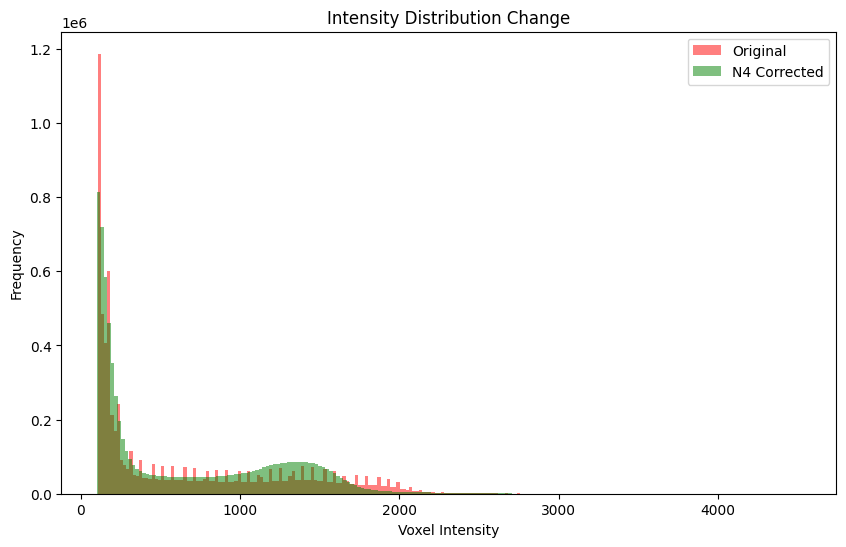

In [3]:
plt.figure(figsize=(10, 6))

# Filter out background (zeros/noise) to see the brain peaks clearly
# Adjust 'threshold' based on your previous histogram (e.g., > 100)
threshold = 100
orig_pixels = original_data[original_data > threshold].ravel()
corr_pixels = corrected_data[corrected_data > threshold].ravel()

plt.hist(orig_pixels, bins=200, alpha=0.5, label='Original', color='red')
plt.hist(corr_pixels, bins=200, alpha=0.5, label='N4 Corrected', color='green')

plt.title("Intensity Distribution Change")
plt.xlabel("Voxel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

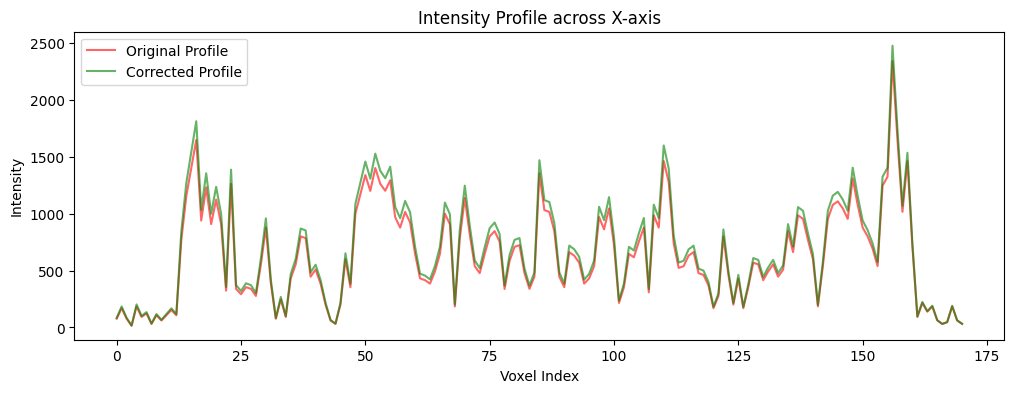

In [4]:
# Pick a row that goes through both hemispheres
row_idx = original_data.shape[1] // 2
line_orig = original_data[slice_idx, row_idx, :]
line_corr = corrected_data[slice_idx, row_idx, :]

plt.figure(figsize=(12, 4))
plt.plot(line_orig, label='Original Profile', color='red', alpha=0.6)
plt.plot(line_corr, label='Corrected Profile', color='green', alpha=0.6)
plt.title("Intensity Profile across X-axis")
plt.xlabel("Voxel Index")
plt.ylabel("Intensity")
plt.legend()
plt.show()

# Brain extraction

In [2]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

In [11]:
# Convert SimpleITK image back to Nibabel Nifti
corrected_data_arr = sitk.GetArrayFromImage(corrected_image)

# SimpleITK uses (z, y, x) order, Nibabel uses (x, y, z)
# We must transpose back to match your original Affine
corrected_data_arr = np.transpose(corrected_data_arr, (2, 1, 0))

# Create a new Nifti image using the original affine
corrected_nifti = nib.Nifti1Image(corrected_data_arr, img.affine)

In [12]:
from nilearn.masking import compute_brain_mask
from nilearn import plotting

# Compute mask on the 'clean' image
# 'opening=2' helps remove those small 'floating' noise pixels you saw earlier
brain_mask = compute_brain_mask(corrected_nifti, opening=2)

# Apply the mask to get the 'Brain-Only' image
from nilearn.image import math_img
brain_only_img = math_img("img * mask", img=corrected_nifti, mask=brain_mask)

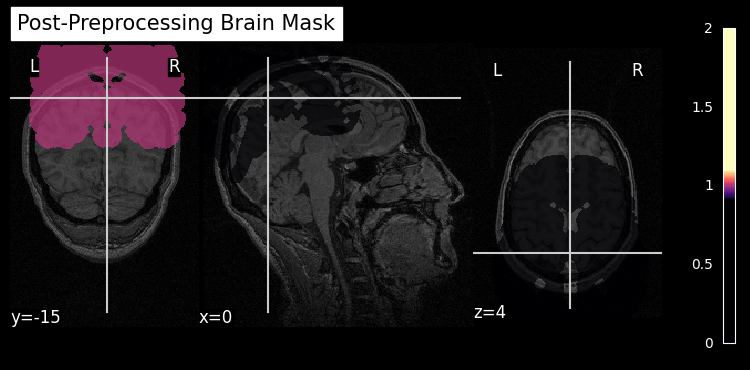

In [13]:
plotting.plot_roi(brain_mask, bg_img=corrected_nifti, 
                  title="Post-Preprocessing Brain Mask",
                  display_mode='ortho', 
                  cmap='magma')
plotting.show()

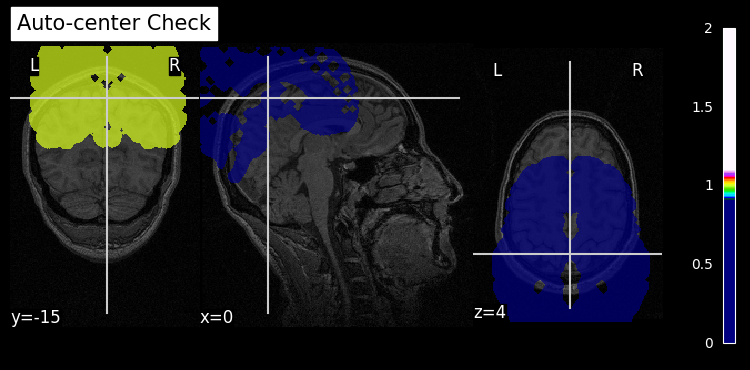

In [27]:
from nilearn.masking import compute_multi_brain_mask
from nilearn.image import threshold_img
from nilearn.image import new_img_like

# Create a version of the image where extreme outliers are removed
# This helps the masking algorithm 'see' the brain peaks better
# img_clipped = threshold_img(img, threshold=20, copy=True) 
# Note: You can also manually clip: data[data > 2000] = 2000


mask = compute_brain_mask(corrected_nifti, opening=3) # 'opening' cleans up small noise pixels

# robust_mask = compute_multi_brain_mask(corrected_nifti)
perfect_alignment_mask = new_img_like(img, mask.get_fdata())
plotting.plot_roi(perfect_alignment_mask, bg_img=corrected_nifti, 
                  cut_coords=None, # This tells Nilearn to find the 'cut' automatically
                  display_mode='ortho', 
                  title="Auto-center Check")
plotting.show()


In [17]:
print(np.allclose(corrected_nifti.affine, brain_mask.affine))

True


# to MNI152 template space

In [3]:
from nilearn.datasets import load_mni152_template

mni_template = load_mni152_template(resolution=1)  # 1mm MNI152
mni_template

In [7]:
import ants

t1_nib = img
t1_ants = ants.from_numpy(img.get_fdata())
mni_ants = ants.from_numpy(mni_template.get_fdata())

In [8]:
registration = ants.registration(
    fixed=mni_ants,        # 目标空间（MNI）
    moving=t1_ants,        # 你的T1
    type_of_transform='SyN'  # 非线性配准（科研标准）
)


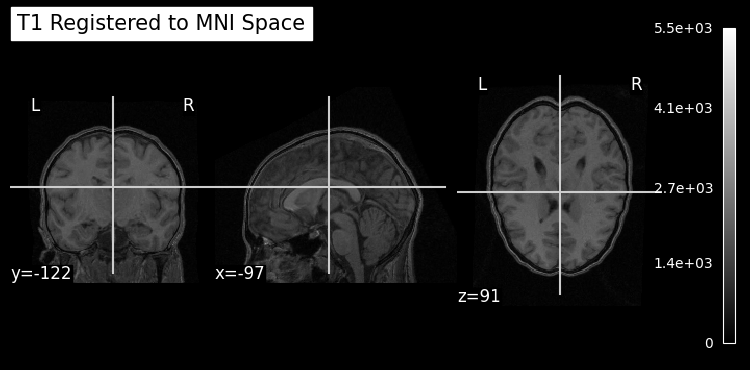

In [15]:
t1_mni_ants = registration['warpedmovout']
# t1_mni_nib = t1_mni_ants.to_nibabel()
t1_mni_ants.to_filename('temp.nii.gz')
t1_mni_nib = nib.load('temp.nii.gz')

from nilearn import plotting
plotting.plot_anat(t1_mni_nib, title="T1 Registered to MNI Space")
plotting.show()


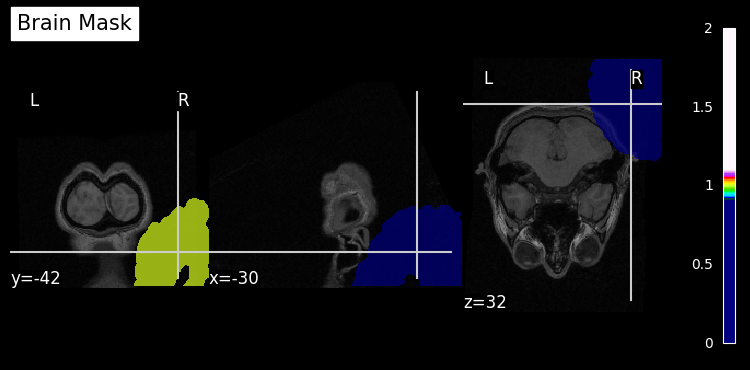

In [23]:
from nilearn.masking import compute_brain_mask

mask = compute_brain_mask(t1_mni_nib)

plotting.plot_roi(mask, bg_img=t1_mni_nib, title="Brain Mask")
plotting.show()

In [22]:
mask.get_fdata().shape

(197, 233, 189)

In [26]:
t1_mni_nib.get_fdata().shape

(197, 233, 189)

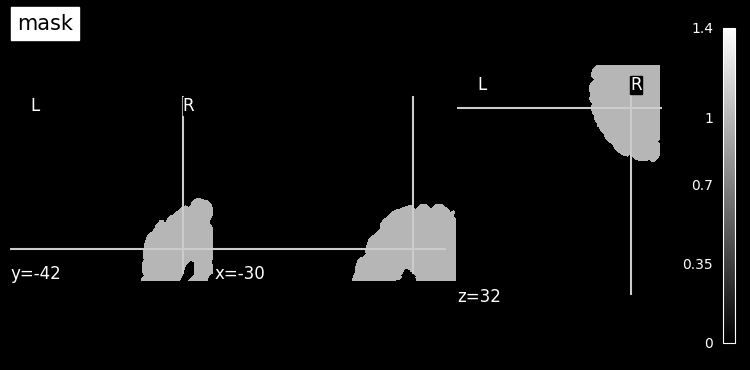

In [28]:
plotting.plot_anat(mask, title="mask")
plotting.show()